<a href="https://www.kaggle.com/code/lalit7881/early-wake-up-exercise-health-outcomes-eda?scriptVersionId=326526769" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aliyasaly1231/early-wake-up-exercise-and-health-outcomes-dataset/early_wakeup_health_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aliyasaly1231/early-wake-up-exercise-and-health-outcomes-dataset/early_wakeup_health_dataset.csv")

In [3]:
df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No


In [4]:
df.tail()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
9995,P09996,66,Male,170.2,86.4,29.84,Nigeria,Teacher,Single,07:11,...,Medium,High,High,Medium,Low,67.8,Good,53.8,Good,No
9996,P09997,70,Male,182.3,86.9,26.14,Canada,Athlete,Single,09:33,...,Medium,High,Medium,Medium,Low,84.8,Excellent,78.5,Excellent,No
9997,P09998,29,Male,170.4,81.2,27.96,Italy,Lawyer,Married,07:58,...,Medium,Low,Medium,Low,Medium,54.2,Average,59.2,Average,No
9998,P09999,22,Male,186.5,78.3,22.52,India,Chef,Single,06:39,...,Low,Medium,Medium,Low,Medium,78.9,Good,84.2,Good,No
9999,P10000,58,Male,177.8,63.9,20.22,Brazil,Freelancer,Single,05:06,...,Low,Low,Low,Low,Low,88.7,Excellent,90.4,Excellent,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  object 
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  object 
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  object 
 7   Occupation                      10000 non-null  object 
 8   Marital_Status                  10000 non-null  object 
 9   Wake_Up_Time                    10000 non-null  object 
 10  Sleep_Time                      10000 non-null  object 
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

In [6]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Sleep_Duration_Hours,Sleep_Quality_Score,Number_of_Night_Awakenings,Weekend_Sleep_Difference_Hours,Nap_Frequency_Per_Week,Screen_Time_Before_Bed_Hours,...,Fatigue_Level_Score,Immune_Health_Score,Mood_Score,Anxiety_Score,Depression_Risk_Score,Productivity_Score,Focus_Concentration_Score,Life_Satisfaction_Score,Health_Score,Healthy_Aging_Score
count,10000.0000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000
mean,44.6667,168.649160,73.10734,25.626963,7.229332,6.020190,0.839100,1.027020,2.120800,1.144012,...,3.124640,6.56333,6.779650,5.133470,2.184520,7.06533,6.85799,7.416720,74.201360,74.812320
std,17.5172,9.876706,16.29195,4.870317,1.118486,1.585689,0.936215,0.787941,1.905196,1.044281,...,1.705843,1.06034,1.255232,1.496242,1.286404,1.14750,0.95254,1.147736,12.266227,14.627688
min,18.0000,145.000000,33.60000,16.000000,4.000000,1.000000,0.000000,-1.000000,0.000000,0.000000,...,1.000000,2.60000,2.000000,1.000000,1.000000,2.80000,3.50000,2.900000,27.300000,12.400000
25%,29.7500,161.400000,61.30000,22.170000,6.470000,4.900000,0.000000,0.497500,0.750000,0.330000,...,1.700000,5.90000,5.900000,4.100000,1.000000,6.30000,6.20000,6.600000,66.000000,65.300000
50%,43.0000,168.200000,72.00000,25.580000,7.230000,6.000000,1.000000,1.030000,2.000000,0.810000,...,2.900000,6.60000,6.800000,5.100000,1.800000,7.00000,6.90000,7.400000,74.600000,75.700000
75%,58.0000,175.500000,83.50000,28.862500,7.980000,7.100000,1.000000,1.560000,3.000000,1.650000,...,4.300000,7.30000,7.700000,6.200000,2.900000,7.90000,7.50000,8.200000,82.800000,85.700000
max,80.0000,205.500000,166.60000,44.560000,10.000000,9.800000,6.000000,3.810000,7.000000,4.000000,...,10.000000,10.00000,10.000000,10.000000,8.800000,10.00000,10.00000,10.000000,100.000000,100.000000


In [7]:
df.isnull()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Person_ID              0
Age                    0
Gender                 0
Height_cm              0
Weight_kg              0
                      ..
Health_Score           0
Fitness_Level          0
Healthy_Aging_Score    0
Wellness_Category      0
Early_Waker            0
Length: 64, dtype: int64

In [10]:
df.dtypes

Person_ID               object
Age                      int64
Gender                  object
Height_cm              float64
Weight_kg              float64
                        ...   
Health_Score           float64
Fitness_Level           object
Healthy_Aging_Score    float64
Wellness_Category       object
Early_Waker             object
Length: 64, dtype: object

In [11]:
df.shape

(10000, 64)

In [12]:
df.nunique()

Person_ID              10000
Age                       63
Gender                     3
Height_cm                516
Weight_kg                847
                       ...  
Health_Score             617
Fitness_Level              4
Healthy_Aging_Score      691
Wellness_Category          4
Early_Waker                2
Length: 64, dtype: int64

In [13]:
df.columns

Index(['Person_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI',
       'Country', 'Occupation', 'Marital_Status', 'Wake_Up_Time', 'Sleep_Time',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score',
       'Number_of_Night_Awakenings', 'Weekend_Sleep_Difference_Hours',
       'Nap_Frequency_Per_Week', 'Screen_Time_Before_Bed_Hours',
       'Exercise_Frequency_Per_Week', 'Exercise_Duration_Minutes',
       'Exercise_Type', 'Daily_Steps', 'Morning_Workout', 'Workout_Intensity',
       'Gym_Member', 'Daily_Calorie_Intake', 'Water_Intake_Liters',
       'Fruit_Intake_Per_Day', 'Vegetable_Intake_Per_Day',
       'Protein_Intake_Grams', 'Sugary_Drinks_Per_Week',
       'Fast_Food_Meals_Per_Week', 'Breakfast_Regularity_Score',
       'Smoking_Status', 'Alcohol_Consumption', 'Stress_Level',
       'Working_Hours_Per_Day', 'Sitting_Hours_Per_Day', 'Outdoor_Time_Hours',
       'Social_Interaction_Score', 'Meditation_Practice', 'Resting_Heart_Rate',
       'Systolic_BP', 'Diastolic_BP', 'Cho

## EDA

In [14]:
plt.style.use('ggplot')
sns.set(font_scale=1.1)


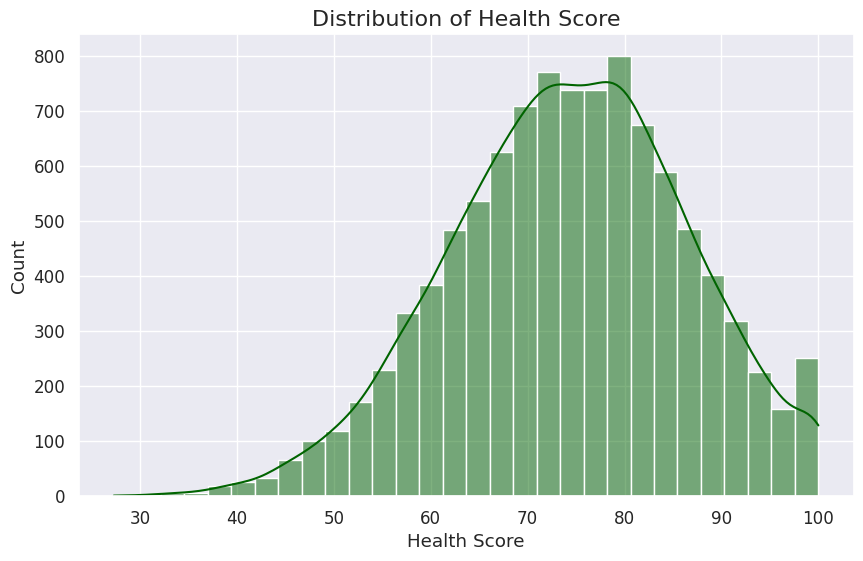

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Health_Score'],
    bins=30,
    kde=True,
    color='darkgreen'
)

plt.title('Distribution of Health Score', fontsize=16)
plt.xlabel('Health Score')
plt.ylabel('Count')
plt.show()

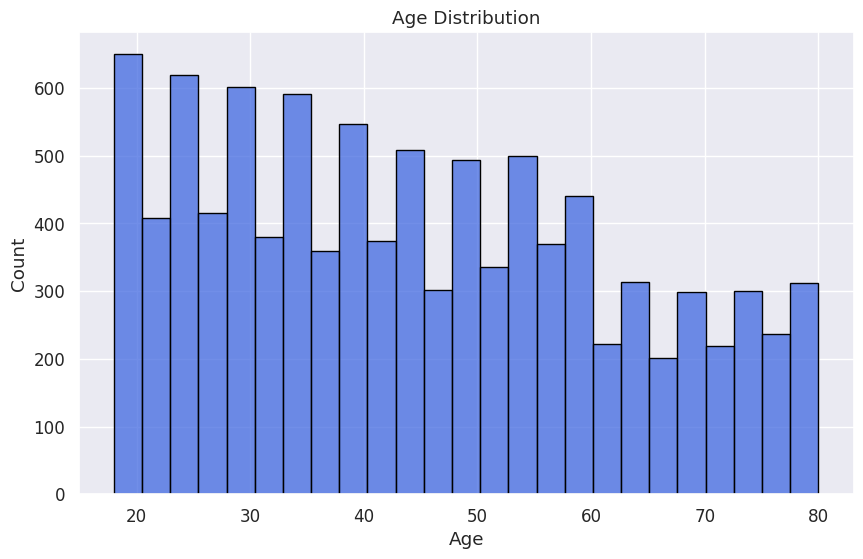

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Age'],
    bins=25,
    color='royalblue',
    edgecolor='black'
)

plt.title('Age Distribution')
plt.show()

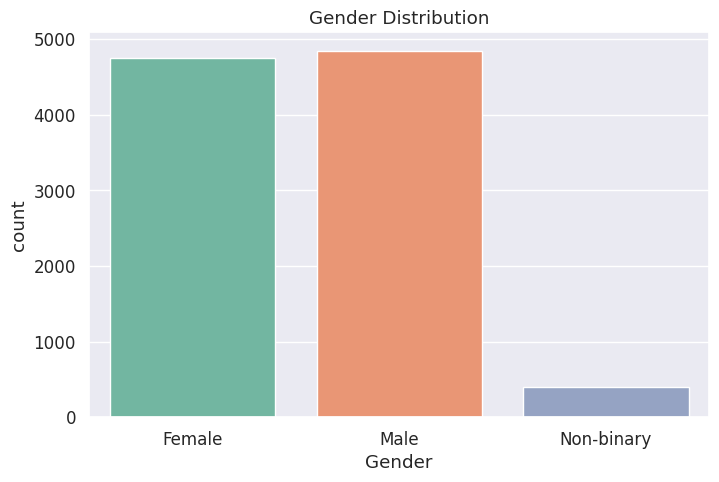

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Gender',
    data=df,
    palette='Set2'
)

plt.title('Gender Distribution')
plt.show()

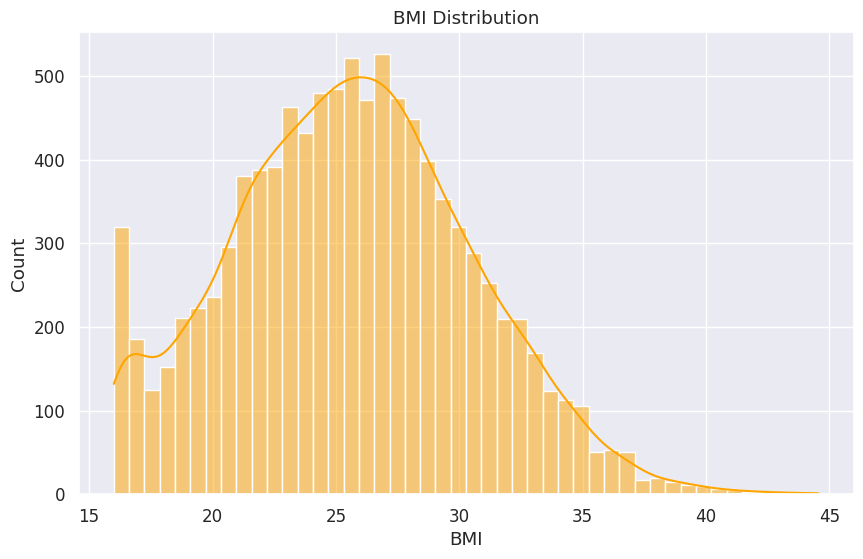

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['BMI'],
    kde=True,
    color='orange'
)

plt.title('BMI Distribution')
plt.show()

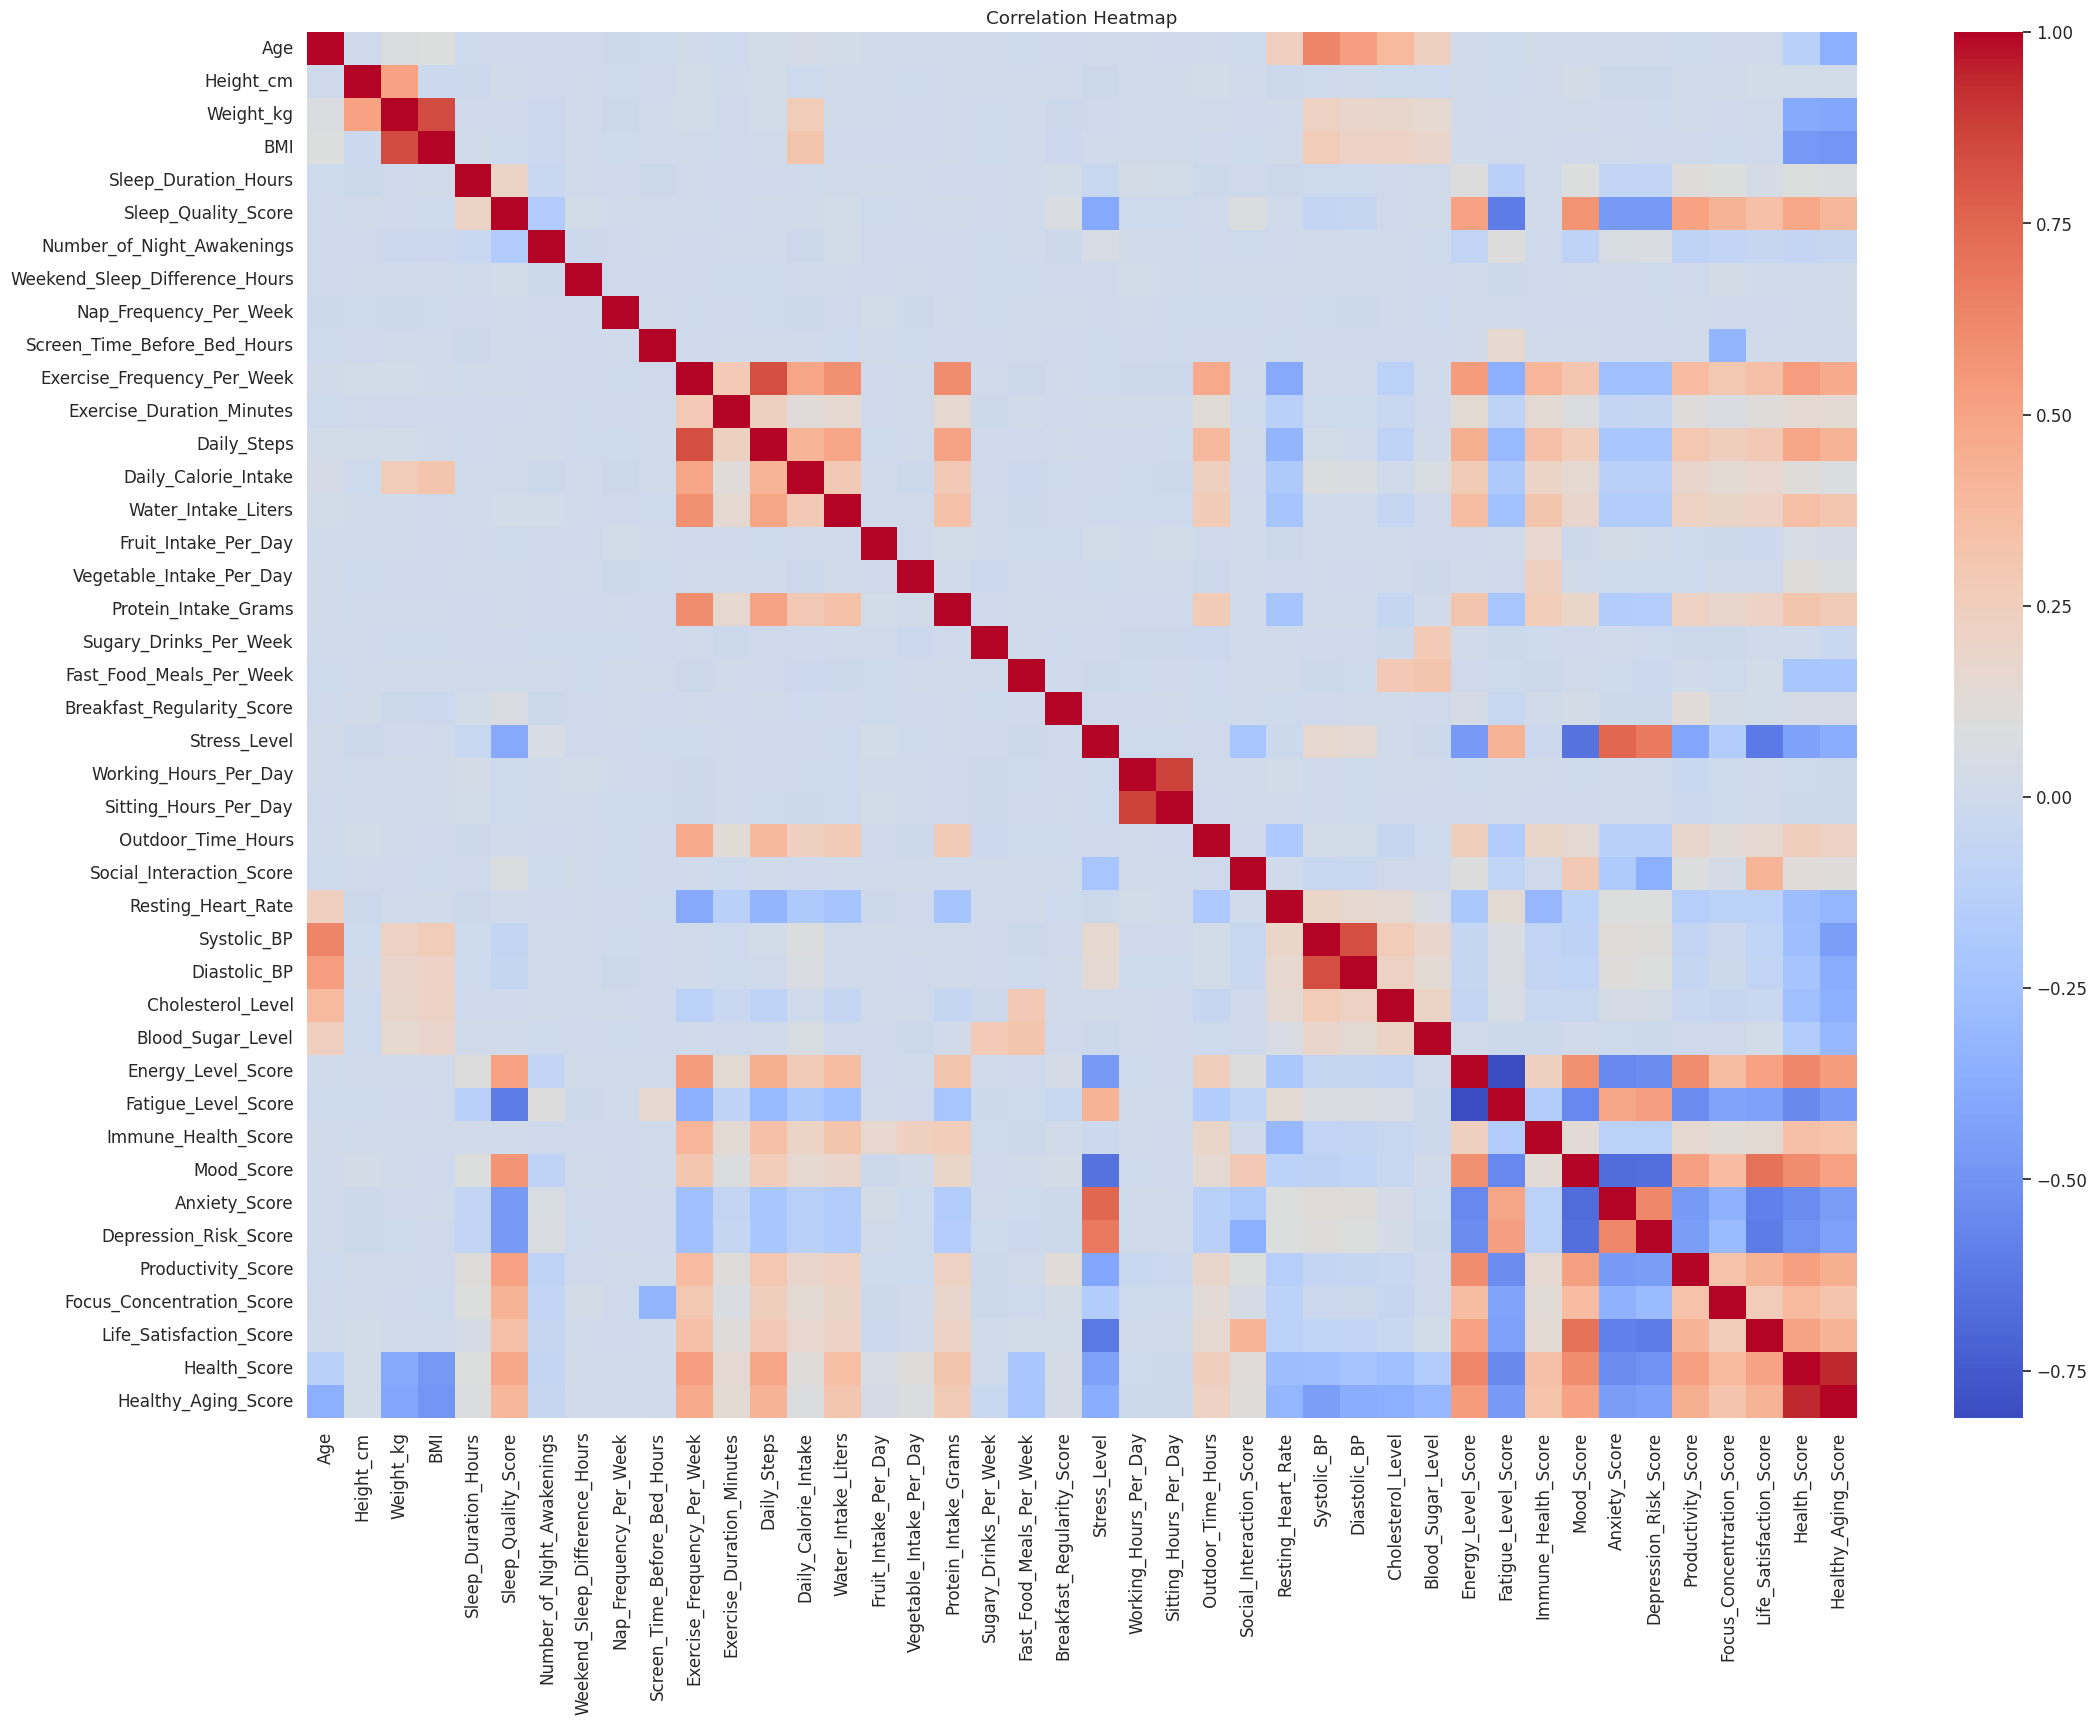

In [19]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(25,18))

sns.heatmap(
    numeric_cols.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')
plt.show()

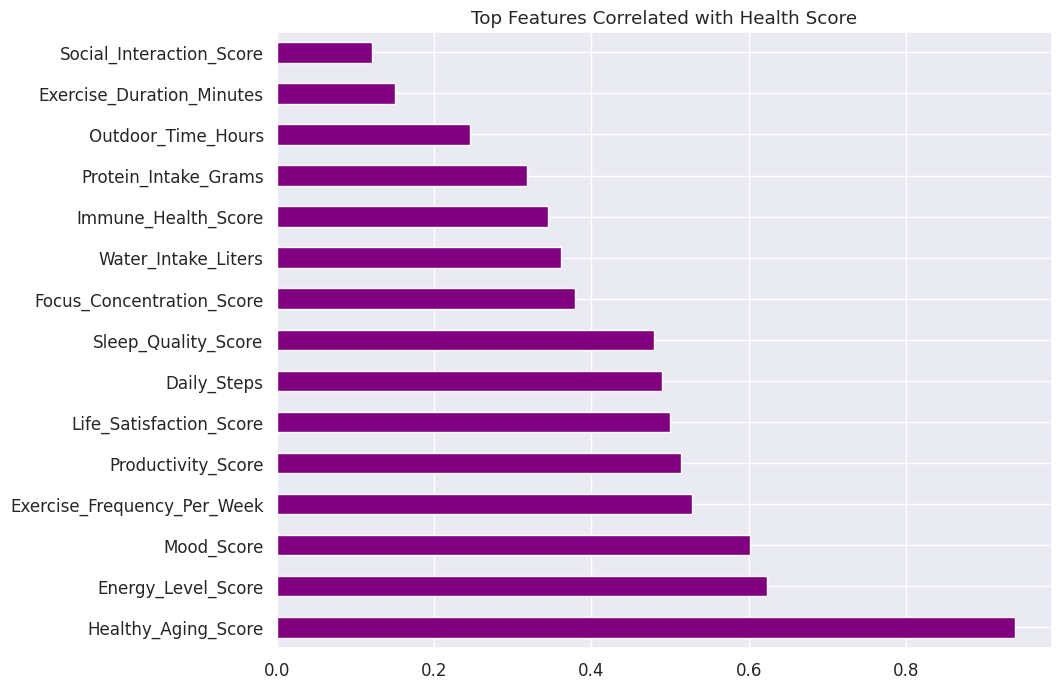

In [20]:
corr = numeric_cols.corr()['Health_Score']

corr = corr.sort_values(ascending=False)

plt.figure(figsize=(10,8))

corr[1:16].plot(
    kind='barh',
    color='purple'
)

plt.title('Top Features Correlated with Health Score')
plt.show()

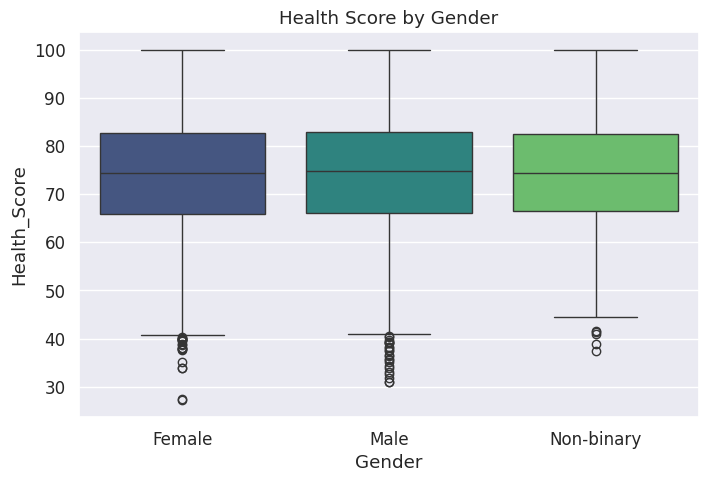

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Gender',
    y='Health_Score',
    data=df,
    palette='viridis'
)

plt.title('Health Score by Gender')
plt.show()

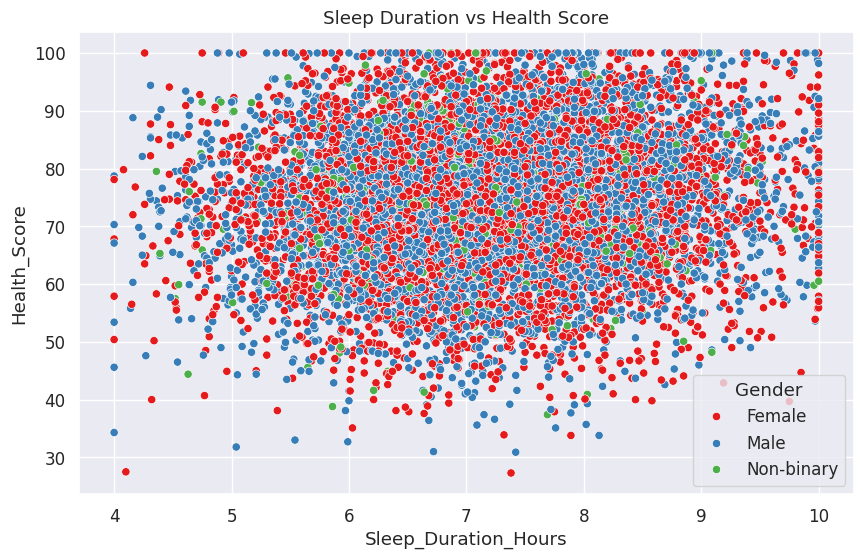

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Sleep_Duration_Hours',
    y='Health_Score',
    hue='Gender',
    palette='Set1',
    data=df
)

plt.title('Sleep Duration vs Health Score')
plt.show()

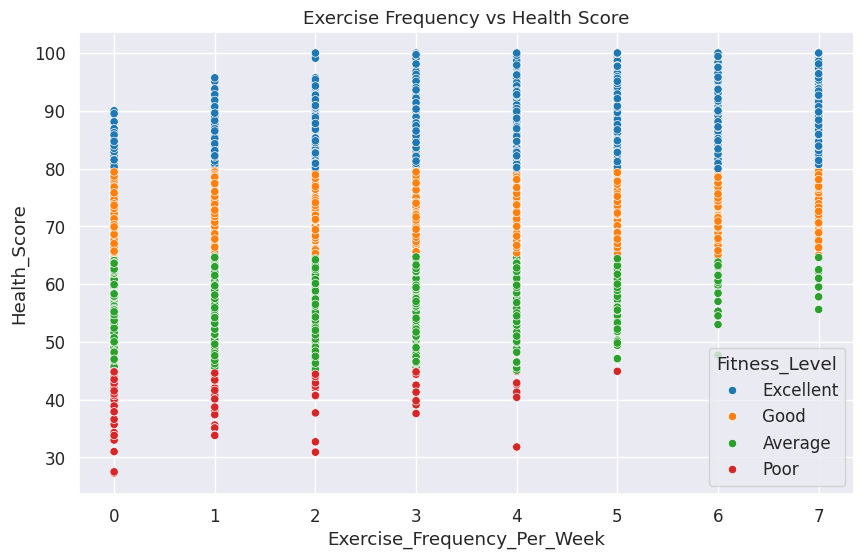

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Exercise_Frequency_Per_Week',
    y='Health_Score',
    hue='Fitness_Level',
    palette='tab10',
    data=df
)

plt.title('Exercise Frequency vs Health Score')
plt.show()

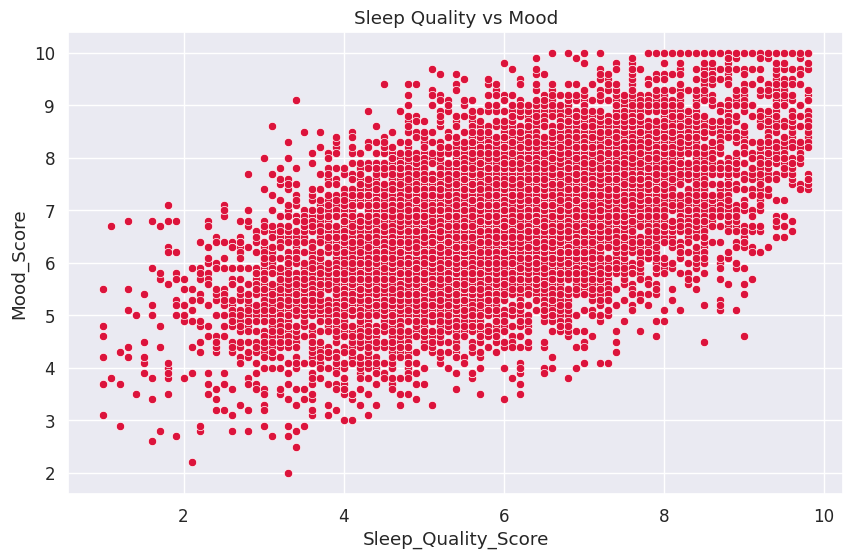

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Sleep_Quality_Score',
    y='Mood_Score',
    color='crimson',
    data=df
)

plt.title('Sleep Quality vs Mood')
plt.show()

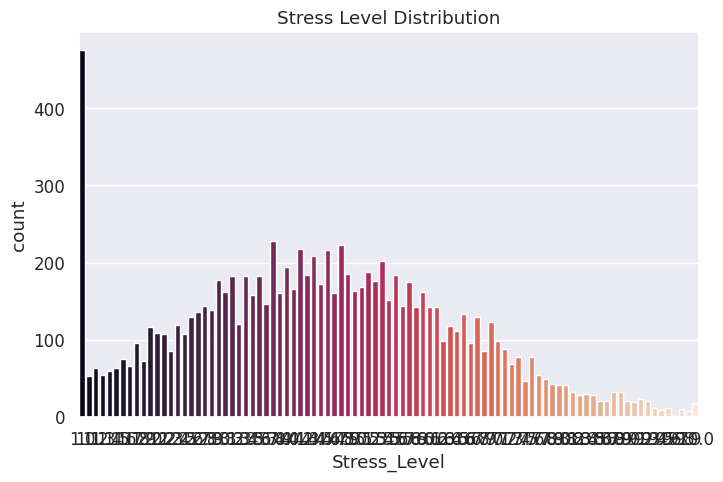

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Stress_Level',
    data=df,
    palette='rocket'
)

plt.title('Stress Level Distribution')
plt.show()

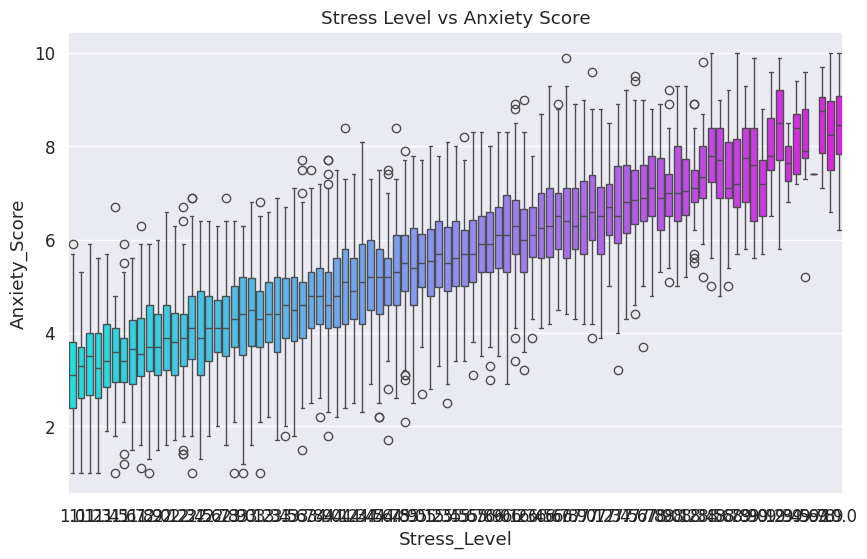

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Stress_Level',
    y='Anxiety_Score',
    data=df,
    palette='cool'
)

plt.title('Stress Level vs Anxiety Score')
plt.show()

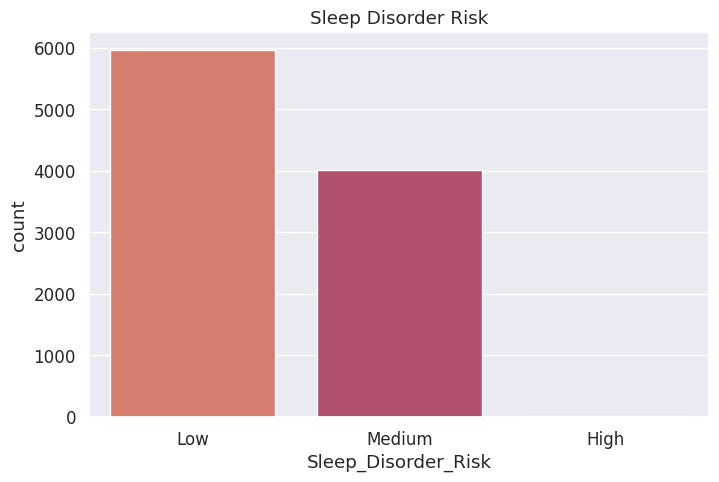

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sleep_Disorder_Risk',
    data=df,
    palette='flare'
)

plt.title('Sleep Disorder Risk')
plt.show()

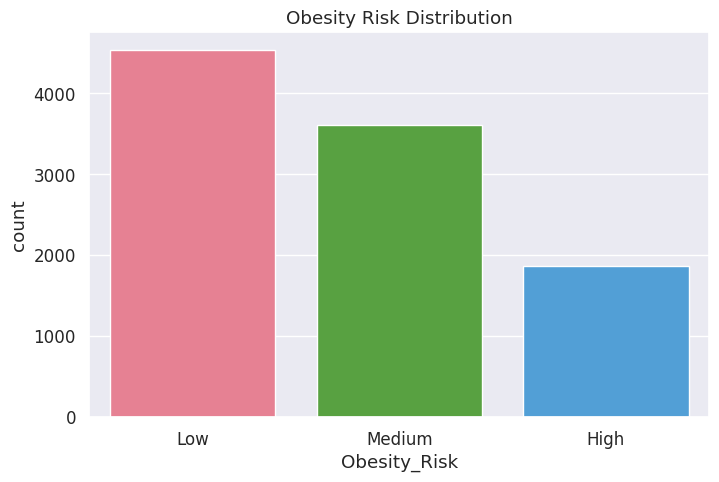

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Obesity_Risk',
    data=df,
    palette='husl'
)

plt.title('Obesity Risk Distribution')
plt.show()

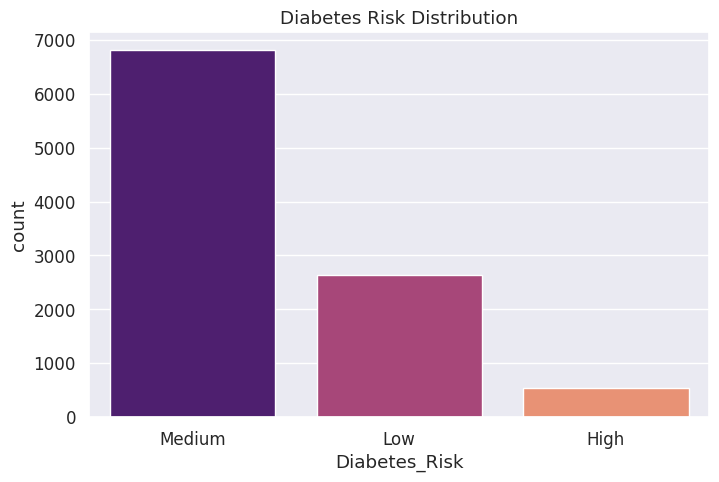

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Diabetes_Risk',
    data=df,
    palette='magma'
)

plt.title('Diabetes Risk Distribution')
plt.show()

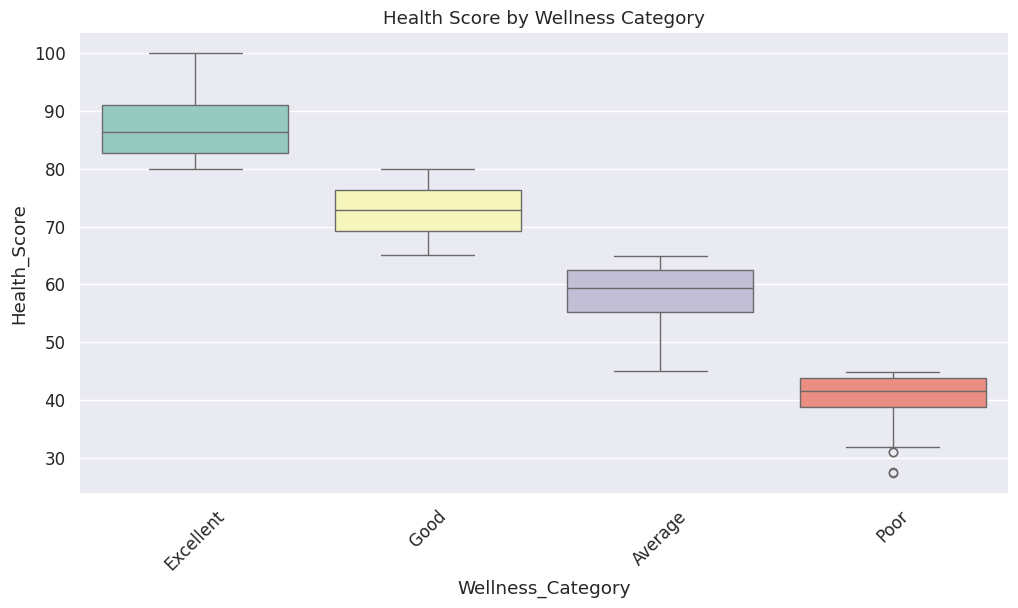

In [30]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Wellness_Category',
    y='Health_Score',
    data=df,
    palette='Set3'
)

plt.xticks(rotation=45)
plt.title('Health Score by Wellness Category')
plt.show()

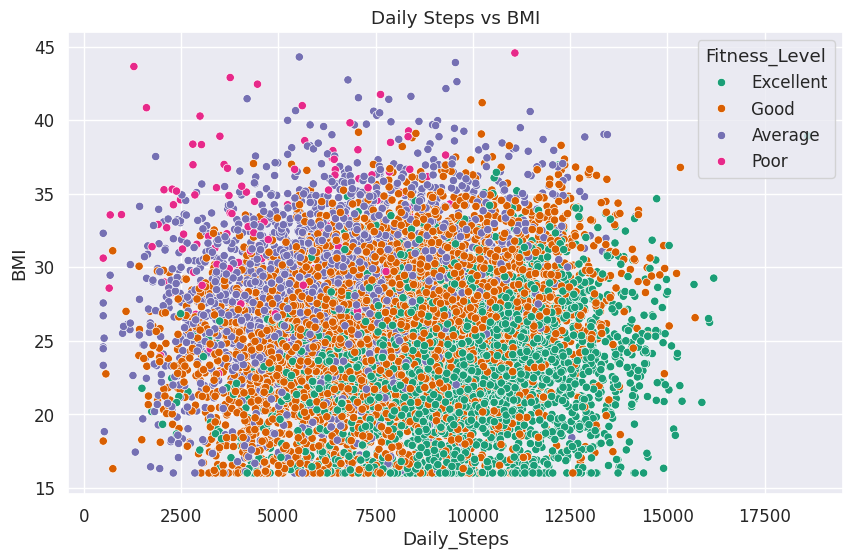

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Daily_Steps',
    y='BMI',
    hue='Fitness_Level',
    palette='Dark2',
    data=df
)

plt.title('Daily Steps vs BMI')
plt.show()

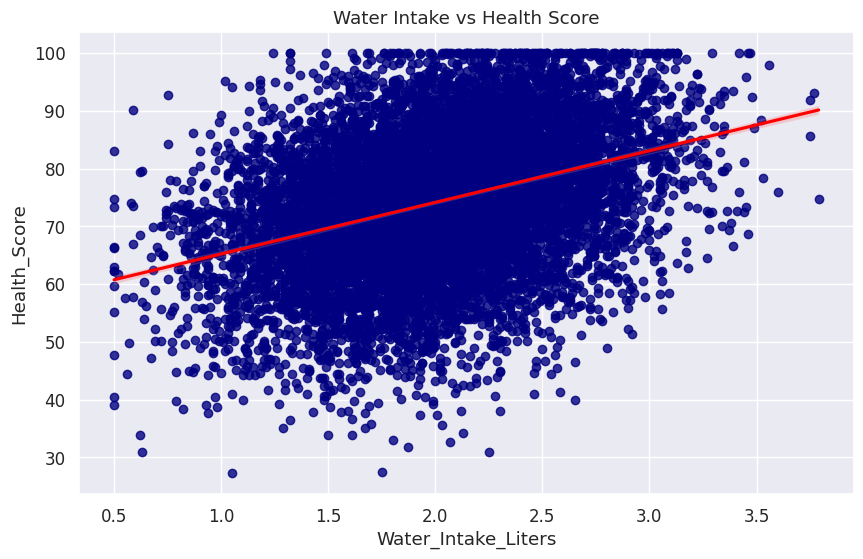

In [32]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='Water_Intake_Liters',
    y='Health_Score',
    data=df,
    scatter_kws={'color':'navy'},
    line_kws={'color':'red'}
)

plt.title('Water Intake vs Health Score')
plt.show()

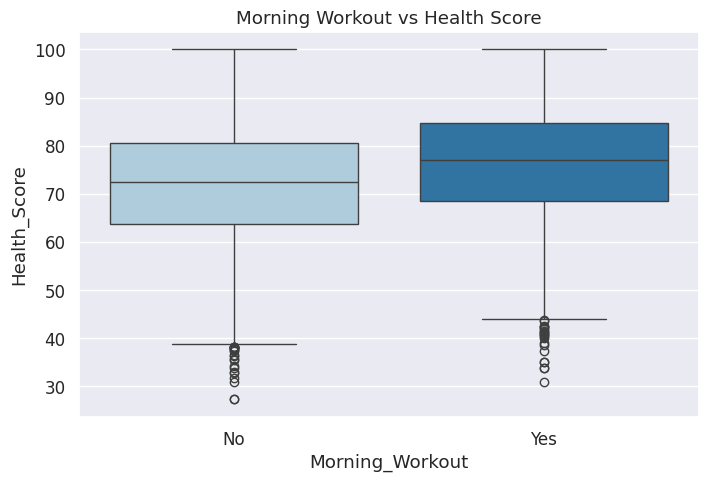

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Morning_Workout',
    y='Health_Score',
    data=df,
    palette='Paired'
)

plt.title('Morning Workout vs Health Score')
plt.show()

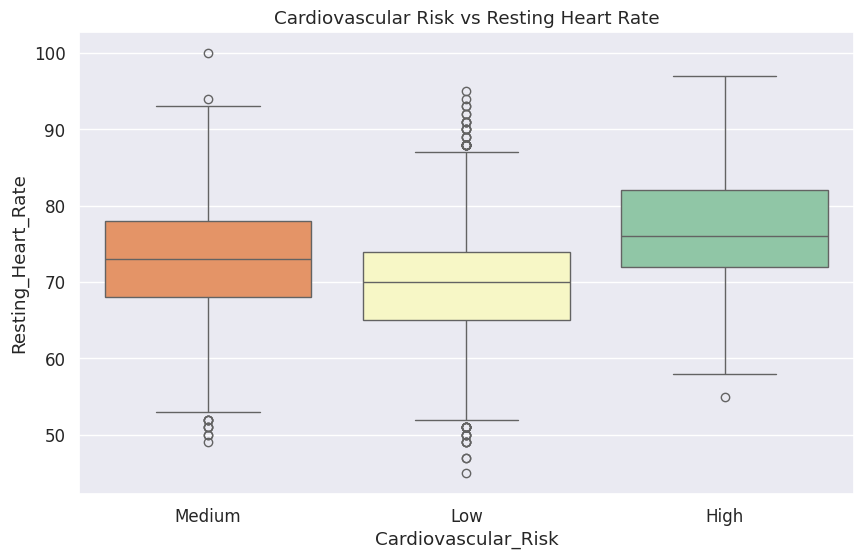

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cardiovascular_Risk',
    y='Resting_Heart_Rate',
    data=df,
    palette='Spectral'
)

plt.title('Cardiovascular Risk vs Resting Heart Rate')
plt.show()

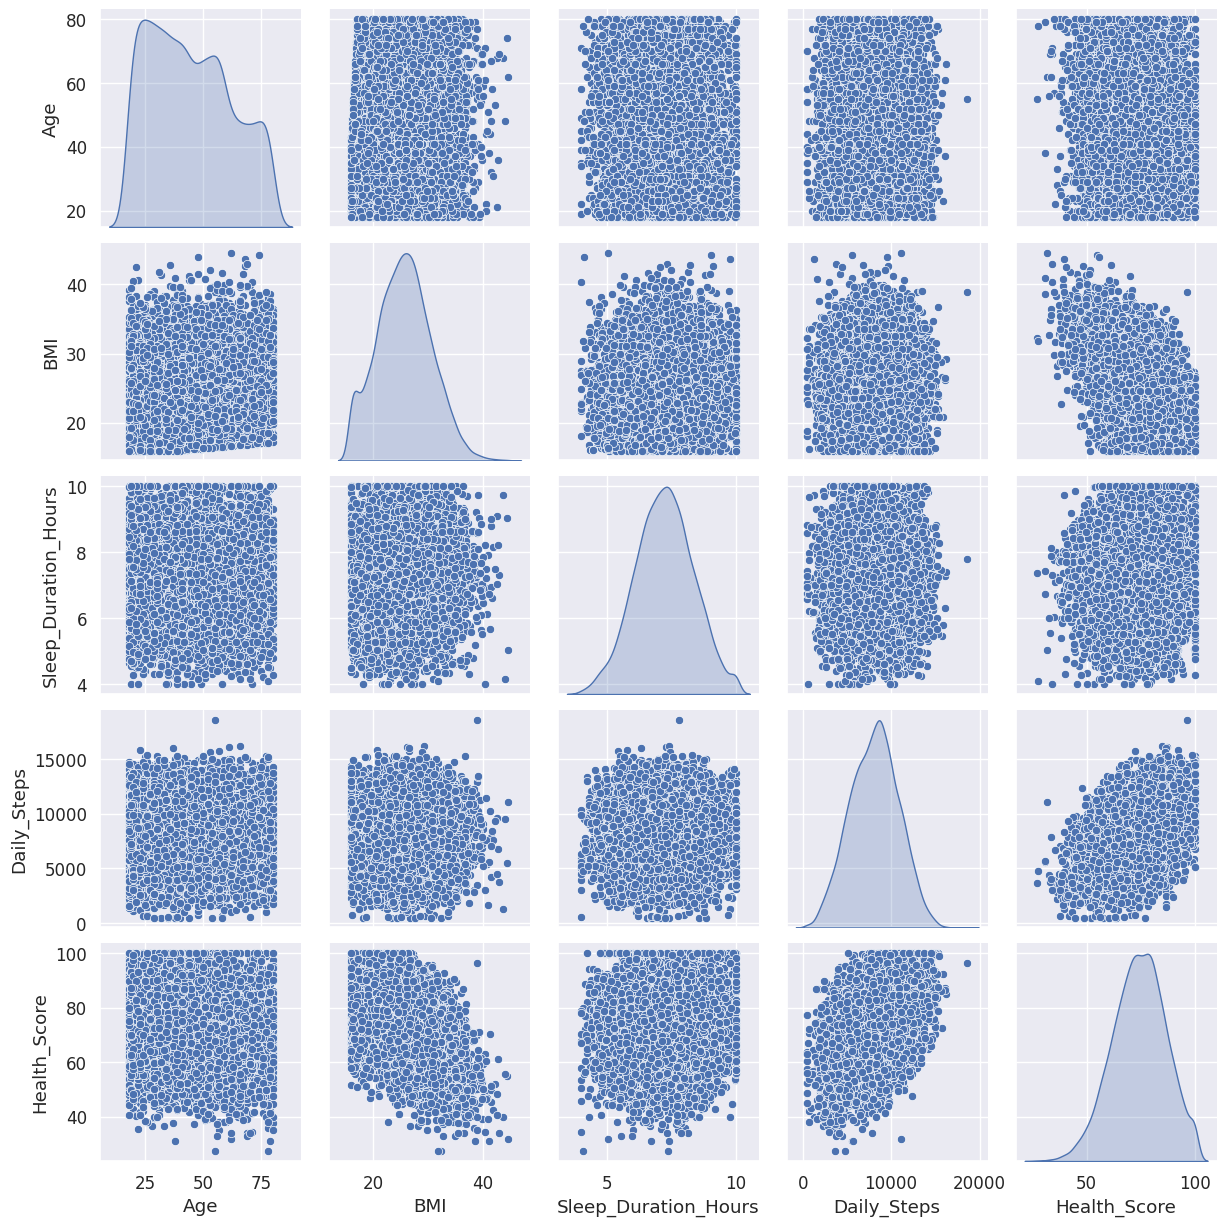

In [35]:
important_features = [
    'Age',
    'BMI',
    'Sleep_Duration_Hours',
    'Daily_Steps',
    'Health_Score'
]

sns.pairplot(
    df[important_features],
    diag_kind='kde'
)

plt.show()

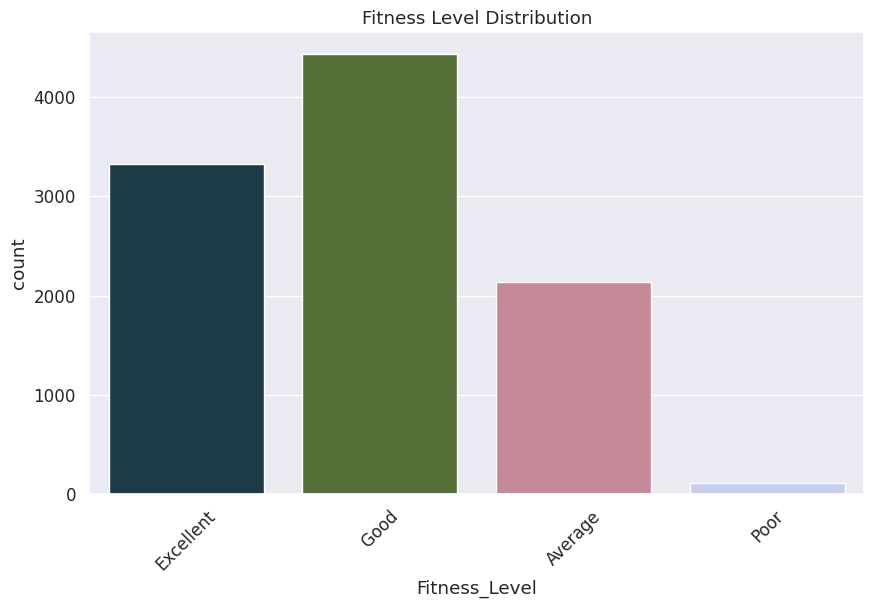

In [36]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Fitness_Level',
    data=df,
    palette='cubehelix'
)

plt.title('Fitness Level Distribution')
plt.xticks(rotation=45)
plt.show()

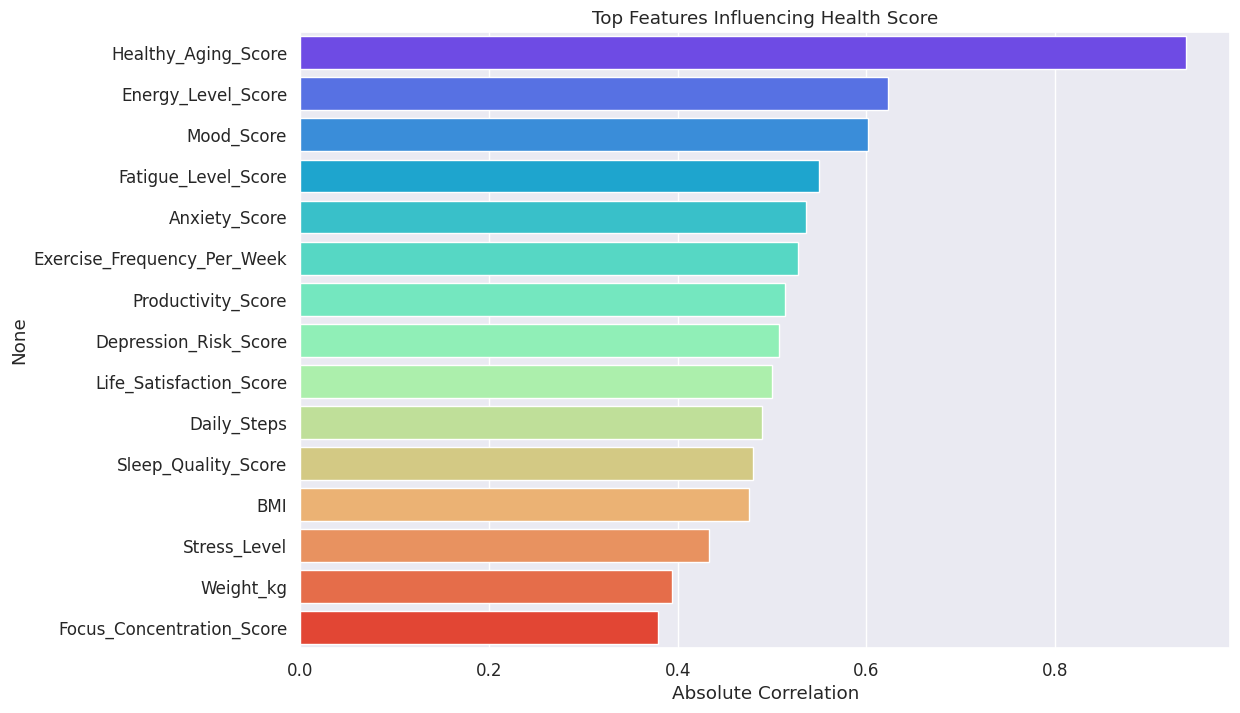

In [37]:
corr = df.select_dtypes(include=np.number).corr()

target_corr = corr['Health_Score'].abs()

target_corr = target_corr.sort_values(
    ascending=False
)[1:16]

plt.figure(figsize=(12,8))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    palette='rainbow'
)

plt.title('Top Features Influencing Health Score')
plt.xlabel('Absolute Correlation')
plt.show()

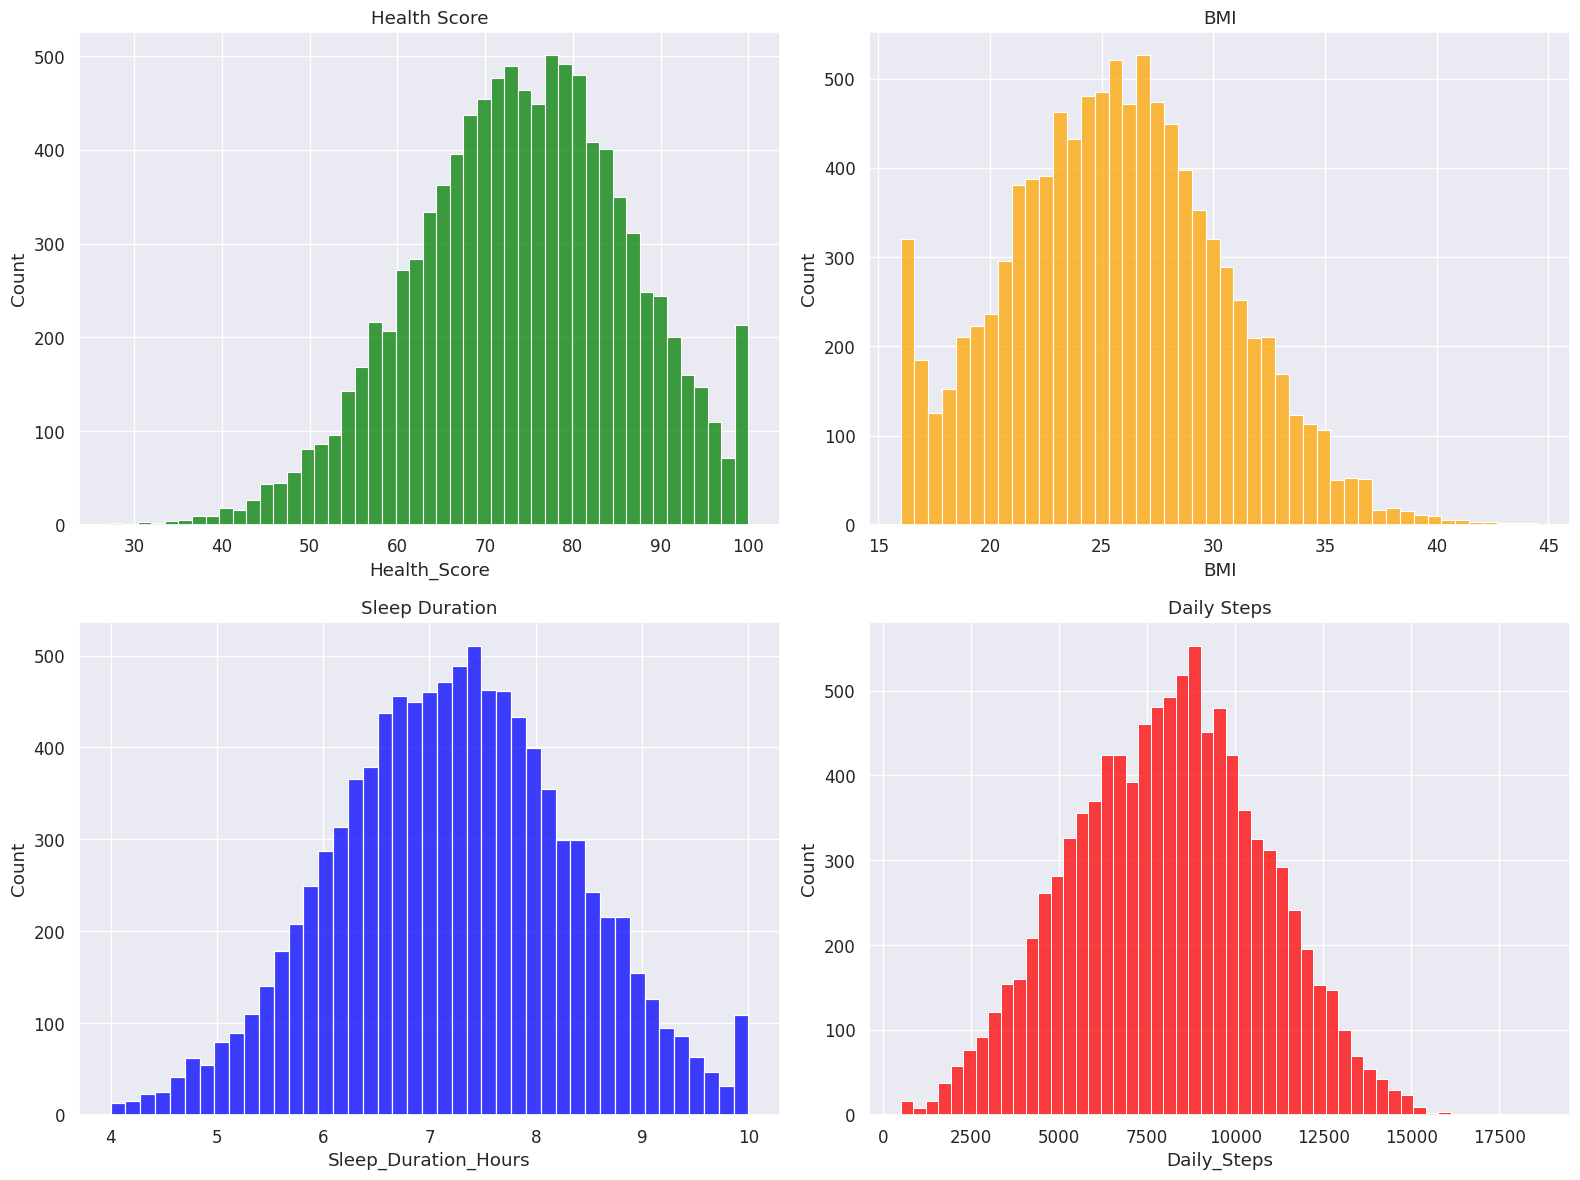

In [38]:
fig, axes = plt.subplots(2,2,figsize=(16,12))

sns.histplot(
    df['Health_Score'],
    color='green',
    ax=axes[0,0]
)

axes[0,0].set_title('Health Score')

sns.histplot(
    df['BMI'],
    color='orange',
    ax=axes[0,1]
)

axes[0,1].set_title('BMI')

sns.histplot(
    df['Sleep_Duration_Hours'],
    color='blue',
    ax=axes[1,0]
)

axes[1,0].set_title('Sleep Duration')

sns.histplot(
    df['Daily_Steps'],
    color='red',
    ax=axes[1,1]
)

axes[1,1].set_title('Daily Steps')

plt.tight_layout()
plt.show()

## Feature Engineering

In [39]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

In [40]:
TARGET = "Wellness_Category"

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [41]:
le = LabelEncoder()

y = le.fit_transform(y)

print("Classes:")
print(le.classes_)

Classes:
['Average' 'Excellent' 'Good' 'Poor']


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (8000, 63)
Test Shape: (2000, 63)


In [43]:
numerical_cols = X_train.select_dtypes(
    include=['int64','float64']
).columns

categorical_cols = X_train.select_dtypes(
    include=['object']
).columns

print("Numerical Features:", len(numerical_cols))
print("Categorical Features:", len(categorical_cols))

Numerical Features: 42
Categorical Features: 21


In [44]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [45]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        random_state=42
    ),

    "KNN":
    KNeighborsClassifier(n_neighbors=7),

    "SVM":
    SVC(
        probability=True,
        random_state=42
    )
}

Logistic Regression
Accuracy: 100.0 %

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       427
           1       1.00      1.00      1.00       664
           2       1.00      1.00      1.00       886
           3       1.00      1.00      1.00        23

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix



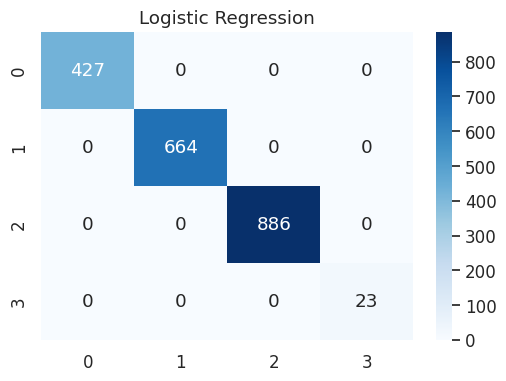

Decision Tree
Accuracy: 100.0 %

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       427
           1       1.00      1.00      1.00       664
           2       1.00      1.00      1.00       886
           3       1.00      1.00      1.00        23

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix



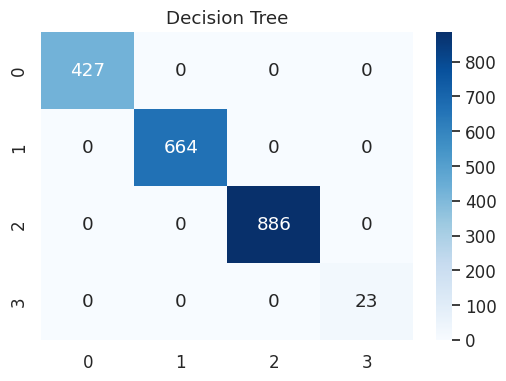

Random Forest
Accuracy: 98.9 %

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       427
           1       1.00      1.00      1.00       664
           2       1.00      1.00      1.00       886
           3       1.00      0.04      0.08        23

    accuracy                           0.99      2000
   macro avg       0.99      0.76      0.76      2000
weighted avg       0.99      0.99      0.98      2000


Confusion Matrix



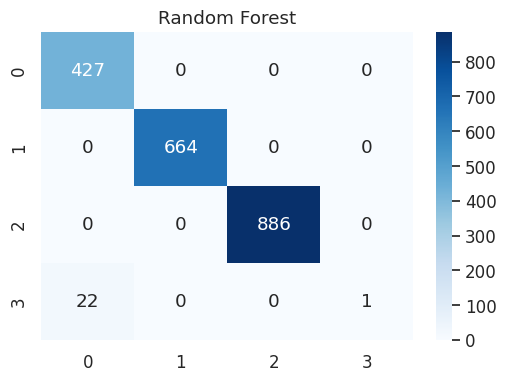

Extra Trees
Accuracy: 99.5 %

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       427
           1       1.00      1.00      1.00       664
           2       1.00      1.00      1.00       886
           3       1.00      0.57      0.72        23

    accuracy                           0.99      2000
   macro avg       0.99      0.89      0.93      2000
weighted avg       1.00      0.99      0.99      2000


Confusion Matrix



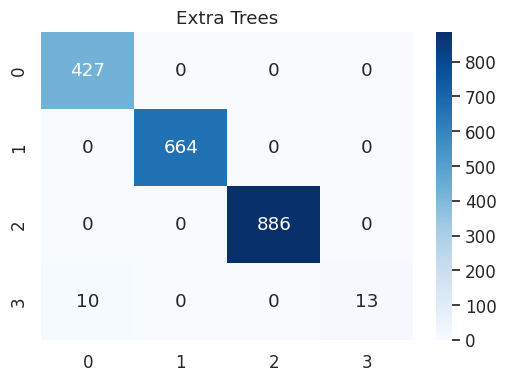

Gradient Boosting
Accuracy: 100.0 %

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       427
           1       1.00      1.00      1.00       664
           2       1.00      1.00      1.00       886
           3       1.00      1.00      1.00        23

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix



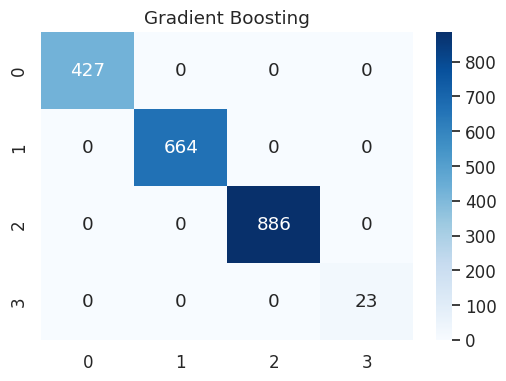

KNN
Accuracy: 90.55 %

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.83      0.87       427
           1       0.95      0.93      0.94       664
           2       0.88      0.94      0.91       886
           3       1.00      0.22      0.36        23

    accuracy                           0.91      2000
   macro avg       0.93      0.73      0.77      2000
weighted avg       0.91      0.91      0.90      2000


Confusion Matrix



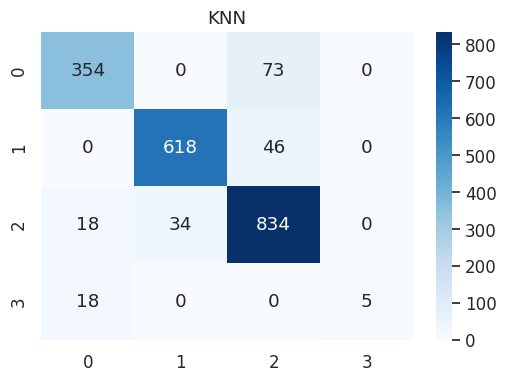

SVM
Accuracy: 99.95 %

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       427
           1       1.00      1.00      1.00       664
           2       1.00      1.00      1.00       886
           3       1.00      0.96      0.98        23

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix



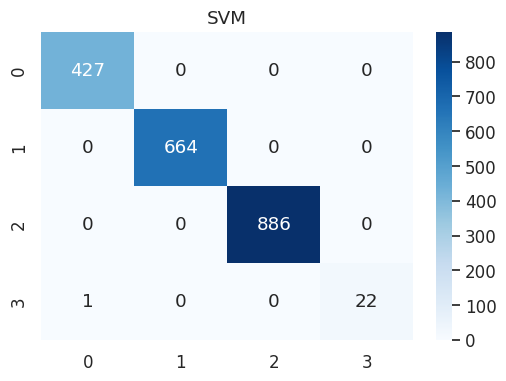

In [46]:
results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    results.append(
        [name, accuracy]
    )

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy:",
          round(accuracy*100,2),
          "%")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    print("\nConfusion Matrix\n")

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(name)
    plt.show()

In [47]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy'
    ]
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df)

                 Model  Accuracy
0  Logistic Regression    1.0000
1        Decision Tree    1.0000
4    Gradient Boosting    1.0000
6                  SVM    0.9995
3          Extra Trees    0.9950
2        Random Forest    0.9890
5                  KNN    0.9055


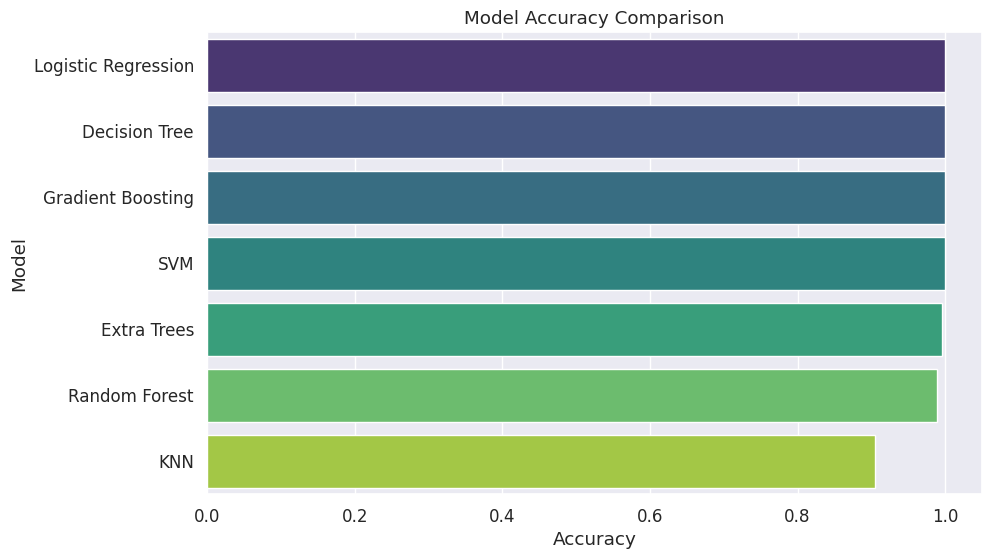

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model',
    palette='viridis'
)

plt.title("Model Accuracy Comparison")

plt.show()

In [49]:
best_model_name = results_df.iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: Logistic Regression


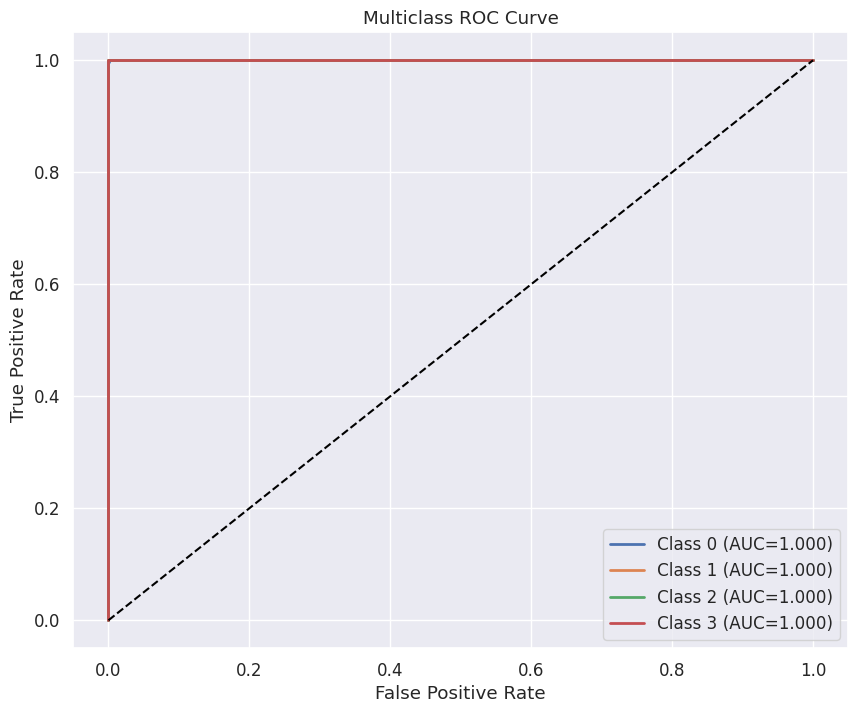

In [50]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc

# Number of classes
classes = np.unique(y)

# Convert y_test to binary matrix
y_test_bin = label_binarize(
    y_test,
    classes=classes
)

# Model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     OneVsRestClassifier(
         RandomForestClassifier(
             n_estimators=300,
             random_state=42
         )
     ))
])

# Train
model.fit(X_train, y_train)

# Probabilities
y_score = model.predict_proba(X_test)

# ROC Curves
plt.figure(figsize=(10,8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'Class {classes[i]} (AUC={roc_auc:.3f})'
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

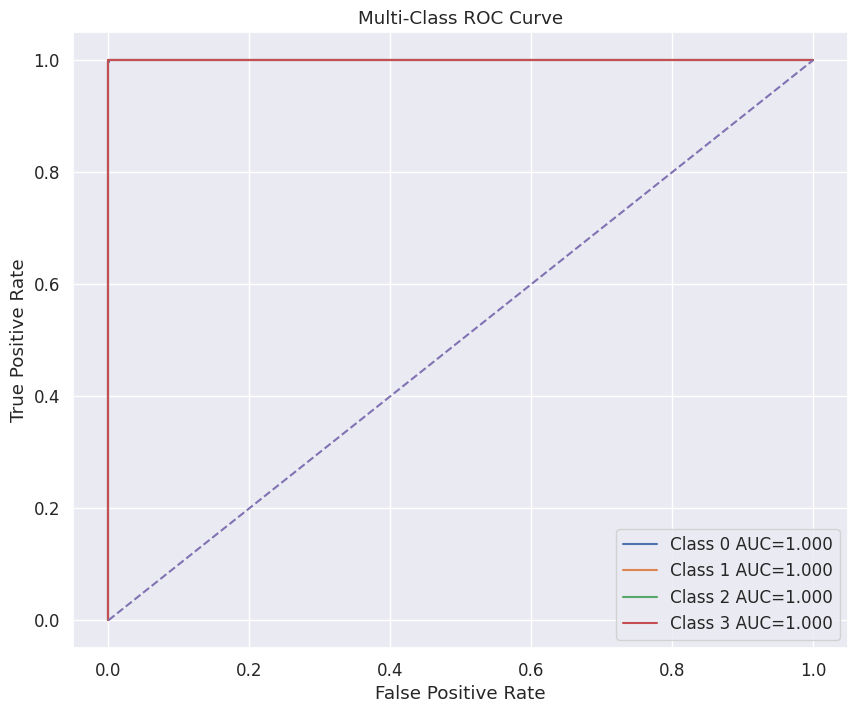

In [51]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

classes = np.unique(y)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
     OneVsRestClassifier(
         RandomForestClassifier(
             n_estimators=300,
             random_state=42
         )
     ))
])

rf.fit(
    X_train,
    y_train
)

y_score = rf.predict_proba(
    X_test
)

plt.figure(figsize=(10,8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} AUC={roc_auc:.3f}'
    )

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multi-Class ROC Curve")

plt.legend()

plt.show()

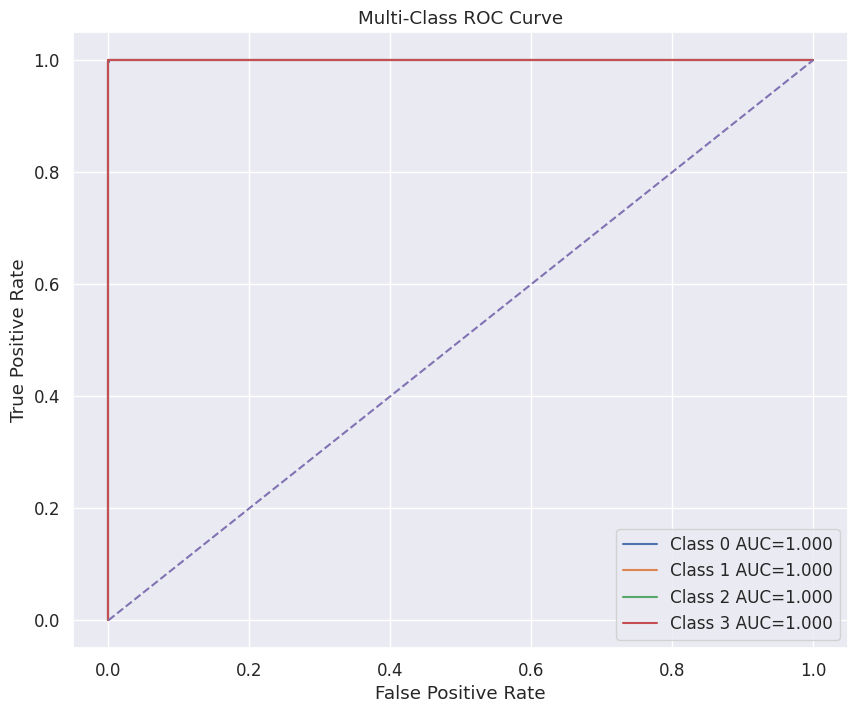

In [52]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

classes = np.unique(y)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
     OneVsRestClassifier(
         RandomForestClassifier(
             n_estimators=300,
             random_state=42
         )
     ))
])

rf.fit(
    X_train,
    y_train
)

y_score = rf.predict_proba(
    X_test
)

plt.figure(figsize=(10,8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} AUC={roc_auc:.3f}'
    )

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multi-Class ROC Curve")

plt.legend()

plt.show()

In [53]:
rf = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model',
         RandomForestClassifier(
             n_estimators=300,
             random_state=42
         ))
    ]
)

rf.fit(
    X_train,
    y_train
)

feature_names = rf.named_steps[
    'preprocessor'
].get_feature_names_out()

importance = rf.named_steps[
    'model'
].feature_importances_

feature_importance = pd.DataFrame(
    {
        'Feature': feature_names,
        'Importance': importance
    }
)

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

                               Feature  Importance
9101           cat__Fitness_Level_Good    0.101976
40                   num__Health_Score    0.099210
9100      cat__Fitness_Level_Excellent    0.078658
41            num__Healthy_Aging_Score    0.073871
9099        cat__Fitness_Level_Average    0.065805
34                     num__Mood_Score    0.017641
32            num__Fatigue_Level_Score    0.016762
3                             num__BMI    0.016668
31             num__Energy_Level_Score    0.016156
35                  num__Anxiety_Score    0.014659
12                    num__Daily_Steps    0.014542
37             num__Productivity_Score    0.014493
5             num__Sleep_Quality_Score    0.014026
2                       num__Weight_kg    0.013360
36          num__Depression_Risk_Score    0.013216
10    num__Exercise_Frequency_Per_Week    0.013094
39        num__Life_Satisfaction_Score    0.012761
21                   num__Stress_Level    0.011305
14            num__Water_Intake

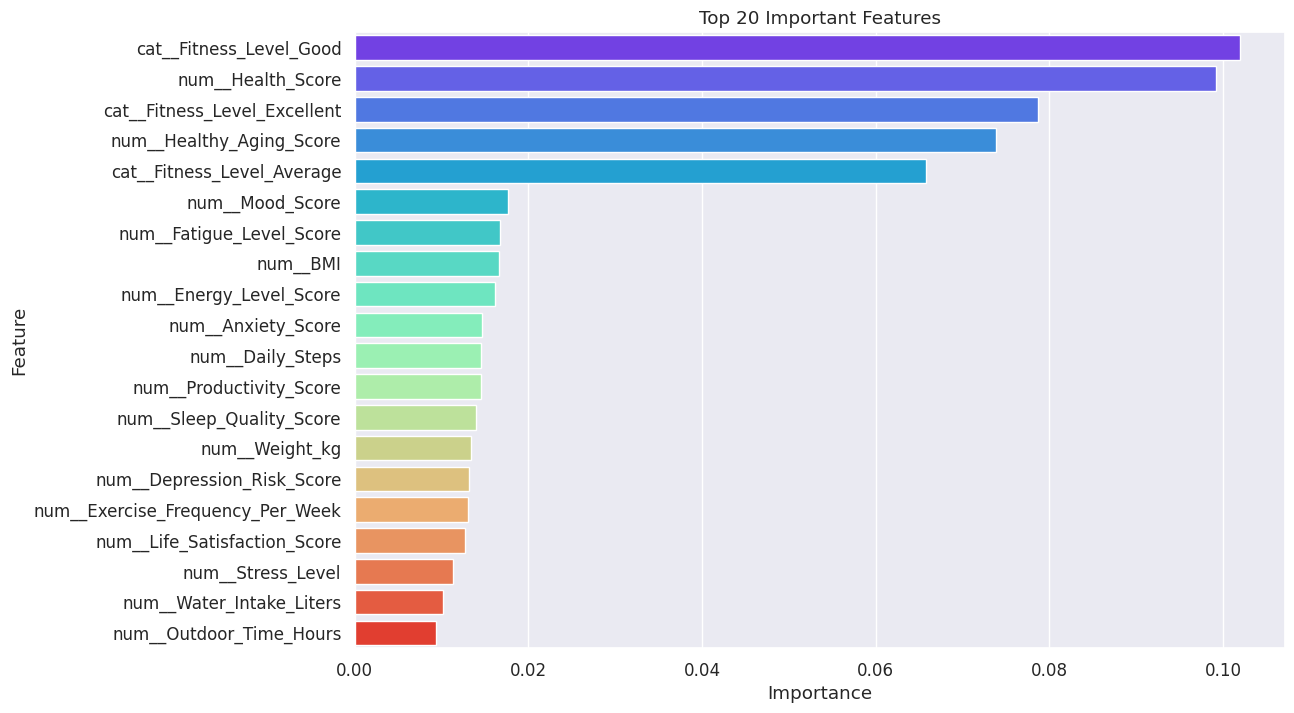

In [54]:
top20 = feature_importance.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top20,
    palette='rainbow'
)

plt.title(
    'Top 20 Important Features'
)

plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!!!!!!!!